In [ ]:
import os
import pickle
import mlflow
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt

from tqdm import tqdm
from numpy import sort
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
from mlflow.models.signature import infer_signature
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.preprocessing import scale, StandardScaler
from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from xgboost import XGBClassifier, plot_importance, XGBRFClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, roc_auc_score

In [ ]:
files = ['two_class_raw_1s_no.csv', 'two_class_raw_1s_yo_0.5.csv', 'two_class_raw_1s_yo_0.8.csv', 'two_class_raw_2s_no.csv', 'two_class_raw_2s_yo_0.5.csv', 'two_class_raw_2s_yo_0.8.csv', 
        'two_class_raw_3s_no.csv', 'two_class_raw_3s_yo_0.5.csv', 'two_class_raw_3s_yo_0.8.csv', 'two_class_raw_4s_no.csv', 'two_class_raw_4s_yo_0.5.csv', 'two_class_raw_4s_yo_0.8.csv',
        'two_class_raw_5s_no.csv', 'two_class_raw_5s_yo_0.5.csv', 'two_class_raw_5s_yo_0.8.csv']

base_path = '/home/edumaba/Public/MPhil_Thesis/Code/uropatch-data-analysis/features_data_main/'

In [ ]:
results = []
for file in files:
    data_path = os.path.join(base_path, file)
    features = pd.read_csv(data_path)
    features.drop(['center_time', 'start_time', 'end_time'], axis=1, inplace=True)
    
    # Extracting the experiment_id from the filename
    details = file.split('_')
    win_overlap = f"{details[3]}_{details[-1].replace('.csv', '')}"
    
    # Split features and labels    
    X = features.drop(columns=['label', 'experiment_id'])
    y = features['label']
    groups = features['experiment_id']

    # Split the data into training and testing sets  
    splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    train_idx, test_idx = next(splitter.split(X, y, groups))

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    groups_train, groups_test = groups.iloc[train_idx], groups.iloc[test_idx]
    
    # Encode labels
    label_encoder = LabelEncoder()
    # Encode y_test and y_train
    y_train_encoded = label_encoder.fit_transform(y_train) 
    y_test_encoded = label_encoder.transform(y_test)
    
    gkf = GroupKFold(n_splits=10)
    
    models = [
    LogisticRegression(random_state=42, max_iter=500),
    DecisionTreeClassifier(random_state=42),
    RandomForestClassifier(random_state=42),
    XGBClassifier(random_state=42, seed=42)
    ]

    for model in models:
        
        cv_scores = cross_val_score(model, X_train, y_train_encoded, groups=groups_train, cv=gkf, scoring='accuracy')
        
        mean_cv_score = round(np.mean(cv_scores) * 100, 2)
        std_cv_score = round(np.std(cv_scores) * 100, 2)
        var_cv_score = round(np.var(cv_scores) * 100, 2)
        
        results.append({
            # 'window_size': window_size,
            # 'overlap': overlap,
            'win_overlap': win_overlap,
            'model': model.__class__.__name__,
            'cv_score': mean_cv_score,
            'std_cv_score': std_cv_score,
            'var_cv_score': var_cv_score,
            # 'feature_importance': feature_importance,
            # 'top_features': feature_importance.head(10)
        })
        

In [ ]:
df = pd.DataFrame(results)
df.head()

In [ ]:
# df.to_csv('/home/edumaba/Public/MPhil_Thesis/Code/uropatch-data-analysis/baseline_analysis/baseline_comparison_results_original_features.csv', index=False)

# Paired t-test across the entire data regardless of model to see if more features increased accuracy.

Results show that there is a significant statistical difference between the groups.

In [2]:
from scipy.stats import ttest_rel
import numpy as np


more_features = pd.read_csv('/home/edumaba/Public/MPhil_Thesis/Code/uropatch-data-analysis/baseline_analysis/baseline_comparison_results_more_features.csv')
original_features = pd.read_csv('/home/edumaba/Public/MPhil_Thesis/Code/uropatch-data-analysis/baseline_analysis/baseline_comparison_results_original_features.csv')

cv_score_more_features = more_features['cv_score'].values
cv_score_original_features = original_features['cv_score'].values

# Perform paired t-test
t_stat, p_value = ttest_rel(cv_score_more_features, cv_score_original_features)

print(f"T-statistic: {t_stat:.3f}, P-value: {p_value:.5f}")

if p_value < 0.05:
    print("Reject H₀: Adding more features leads to a statistically significant difference in performance.")
else:
    print("Fail to reject H₀: No statistically significant difference.")

T-statistic: 7.361, P-value: 0.00000
Reject H₀: Adding more features leads to a statistically significant difference in performance.


In [3]:
mean_diff = np.mean(cv_score_more_features - cv_score_original_features)
std_diff = np.std(cv_score_more_features - cv_score_original_features, ddof=1)
cohens_d = mean_diff / std_diff
print(f"Cohen's d: {cohens_d:.3f}")  # d > 0.8 → large effect

Cohen's d: 0.950


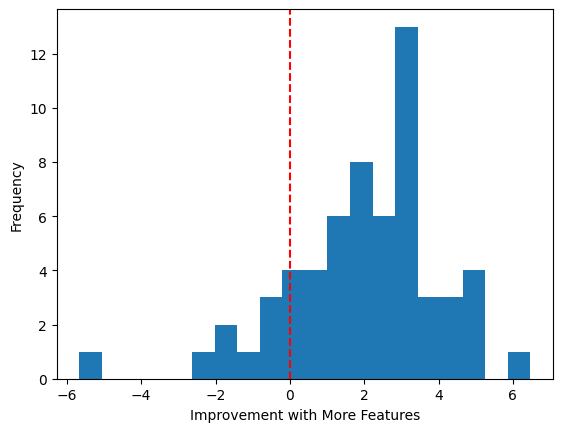

In [4]:
import matplotlib.pyplot as plt
plt.hist(cv_score_more_features - cv_score_original_features, bins=20)
plt.xlabel("Improvement with More Features")
plt.ylabel("Frequency")
plt.axvline(0, color='red', linestyle='--')
plt.show()

In [5]:
models = [
    LogisticRegression(random_state=42, max_iter=500),
    DecisionTreeClassifier(random_state=42),
    RandomForestClassifier(random_state=42),
    XGBClassifier(random_state=42, seed=42)
    ]

In [6]:
original_scores_ = {
    model: original_features[original_features['model'] == model.__class__.__name__]['cv_score'].tolist()
    for model in models
}

more_features_scores_ = {
    model: more_features[more_features['model'] == model.__class__.__name__]['cv_score'].tolist()
    for model in models
}

# Perform paired t-test for each model
for model in models:
    t_stat, p_val = ttest_rel(
        original_scores_[model], 
        more_features_scores_[model]
    )
    print(
        f"{model.__class__.__name__}: t={t_stat:.3f}, p={p_val:.5f} | "
        f"Mean Original: {np.mean(original_scores_[model]):.3f}, "
        f"Mean More Features: {np.mean(more_features_scores_[model]):.3f}"
    )

LogisticRegression: t=-4.556, p=0.00045 | Mean Original: 64.300, Mean More Features: 67.016
DecisionTreeClassifier: t=-1.931, p=0.07394 | Mean Original: 59.769, Mean More Features: 61.203
RandomForestClassifier: t=-4.729, p=0.00032 | Mean Original: 68.265, Mean More Features: 70.283
XGBClassifier: t=-5.944, p=0.00004 | Mean Original: 64.955, Mean More Features: 66.790


In [7]:
def cohens_d(orig, more):
    n = len(orig)
    std_pooled = np.sqrt((np.std(orig, ddof=1)**2 + np.std(more, ddof=1)**2) / 2)
    return (np.mean(more) - np.mean(orig)) / std_pooled

for model in models:
    d = cohens_d(original_scores_[model], more_features_scores_[model])
    print(f"{model.__class__.__name__}: Cohen’s d = {d:.3f}")

LogisticRegression: Cohen’s d = 1.824
DecisionTreeClassifier: Cohen’s d = 0.745
RandomForestClassifier: Cohen’s d = 1.248
XGBClassifier: Cohen’s d = 1.474


Standard Deviation analysis

In [11]:
original_features.head()

,win_overlap,model,cv_score,std_cv_score,var_cv_score
0,1s_no,LogisticRegression,63.27,7.03,0.49
1,1s_no,DecisionTreeClassifier,58.12,7.26,0.53
2,1s_no,RandomForestClassifier,66.93,6.28,0.39
3,1s_no,XGBClassifier,65.27,8.34,0.70
4,1s_0.5,LogisticRegression,63.53,8.65,0.75


In [16]:
original_std_ = {
    model: original_features[original_features['model'] == model.__class__.__name__]['std_cv_score'].tolist()
    for model in models
}

more_features_std_ = {
    model: more_features[more_features['model'] == model.__class__.__name__]['std_cv_score'].tolist()
    for model in models
}

In [17]:
for model in models:
    mean_std_original = np.mean(original_std_[model])
    mean_std_more = np.mean(more_features_std_[model])
    
    print(
        f"{model.__class__.__name__}: "
        f"Mean Std (Original) = {mean_std_original:.3f}, "
        f"Mean Std (More Features) = {mean_std_more:.3f} | "
        f"Δ = {mean_std_more - mean_std_original:+.3f}"
    )

LogisticRegression: Mean Std (Original) = 8.709, Mean Std (More Features) = 7.677 | Δ = -1.033
DecisionTreeClassifier: Mean Std (Original) = 7.983, Mean Std (More Features) = 7.443 | Δ = -0.540
RandomForestClassifier: Mean Std (Original) = 9.748, Mean Std (More Features) = 8.923 | Δ = -0.825
XGBClassifier: Mean Std (Original) = 9.741, Mean Std (More Features) = 9.285 | Δ = -0.455


In [18]:
from scipy.stats import levene

for model in models:
    stat, p_val = levene(original_std_[model], more_features_std_[model])
    print(
        f"{model.__class__.__name__}: "
        f"p-value = {p_val:.5f} "
        f"(H₀: Equal variance {'rejected' if p_val < 0.05 else 'not rejected'})"
    )

LogisticRegression: p-value = 0.60035 (H₀: Equal variance not rejected)
DecisionTreeClassifier: p-value = 0.74896 (H₀: Equal variance not rejected)
RandomForestClassifier: p-value = 0.61574 (H₀: Equal variance not rejected)
XGBClassifier: p-value = 0.90856 (H₀: Equal variance not rejected)


In [19]:
original_features.head()

,win_overlap,model,cv_score,std_cv_score,var_cv_score
0,1s_no,LogisticRegression,63.27,7.03,0.49
1,1s_no,DecisionTreeClassifier,58.12,7.26,0.53
2,1s_no,RandomForestClassifier,66.93,6.28,0.39
3,1s_no,XGBClassifier,65.27,8.34,0.70
4,1s_0.5,LogisticRegression,63.53,8.65,0.75


# Wilcoxon

In [20]:
from scipy.stats import wilcoxon
import numpy as np
import pandas as pd

# Load data
more_features = pd.read_csv('/home/edumaba/Public/MPhil_Thesis/Code/uropatch-data-analysis/baseline_analysis/baseline_comparison_results_more_features.csv')
original_features = pd.read_csv('/home/edumaba/Public/MPhil_Thesis/Code/uropatch-data-analysis/baseline_analysis/baseline_comparison_results_original_features.csv')

cv_score_more = more_features['cv_score'].values
cv_score_original = original_features['cv_score'].values

# Perform Wilcoxon signed-rank test
stat, p_value = wilcoxon(cv_score_more, cv_score_original)
print(f"Wilcoxon Statistic: {stat:.3f}, P-value: {p_value:.5f}")

if p_value < 0.05:
    print("Reject H₀: Adding more features leads to statistically significant improvement.")
else:
    print("Fail to reject H₀: No significant difference.")

Wilcoxon Statistic: 168.000, P-value: 0.00000
Reject H₀: Adding more features leads to statistically significant improvement.


In [22]:
from scipy.stats import shapiro

differences = cv_score_more - cv_score_original
_, p_normality = shapiro(differences)
print(f"Shapiro-Wilk P-value: {p_normality:.5f}")

if p_normality < 0.05:
    print("Differences are non-normal → Use Wilcoxon.")
else:
    print("Differences are normal → t-test is acceptable.")

Shapiro-Wilk P-value: 0.03956
Differences are non-normal → Use Wilcoxon.


In [23]:
original_scores_ = {
    model: original_features[original_features['model'] == model.__class__.__name__]['cv_score'].tolist()
    for model in models
}

more_features_scores_ = {
    model: more_features[more_features['model'] == model.__class__.__name__]['cv_score'].tolist()
    for model in models
}

# Perform paired t-test for each model
for model in models:
    stat, p_val = wilcoxon(
        original_scores_[model], 
        more_features_scores_[model]
    )
    print(
        f"{model.__class__.__name__}: t={stat:.3f}, p={p_val:.5f} | "
        f"Mean Original: {np.mean(original_scores_[model]):.3f}, "
        f"Mean More Features: {np.mean(more_features_scores_[model]):.3f}"
    )

LogisticRegression: t=8.000, p=0.00153 | Mean Original: 64.300, Mean More Features: 67.016
DecisionTreeClassifier: t=27.000, p=0.06372 | Mean Original: 59.769, Mean More Features: 61.203
RandomForestClassifier: t=8.000, p=0.00314 | Mean Original: 68.265, Mean More Features: 70.283
XGBClassifier: t=1.000, p=0.00012 | Mean Original: 64.955, Mean More Features: 66.790


In [24]:
median_diff = np.median(cv_score_more - cv_score_original)
print(f"Median improvement: {median_diff:.3f}")

Median improvement: 2.205


In [25]:
from scipy.stats import wilcoxon
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load data
more_features = pd.read_csv('/home/edumaba/Public/MPhil_Thesis/Code/uropatch-data-analysis/baseline_analysis/baseline_comparison_results_more_features.csv')
original_features = pd.read_csv('/home/edumaba/Public/MPhil_Thesis/Code/uropatch-data-analysis/baseline_analysis/baseline_comparison_results_original_features.csv')

cv_more = more_features['cv_score'].values
cv_original = original_features['cv_score'].values

# Wilcoxon test
stat, p_value = wilcoxon(cv_more, cv_original)
median_diff = np.median(cv_more - cv_original)

print(f"Wilcoxon Statistic = {stat:.3f}, p = {p_value:.5f}")
print(f"Median Improvement = {median_diff:.3f}")

if p_value < 0.05:
    print("✅ Significant: More features improve performance (p < 0.05)")
else:
    print("❌ Not significant: No evidence that more features help")

Wilcoxon Statistic = 168.000, p = 0.00000
Median Improvement = 2.205
✅ Significant: More features improve performance (p < 0.05)


In [26]:
from cliffs_delta import cliffs_delta
d, res = cliffs_delta(cv_more, cv_original)
print(f"Cliff’s Delta = {d:.3f} ({res})")  # e.g., "Negligible", "Small", "Large"

Cliff’s Delta = 0.344 (medium)


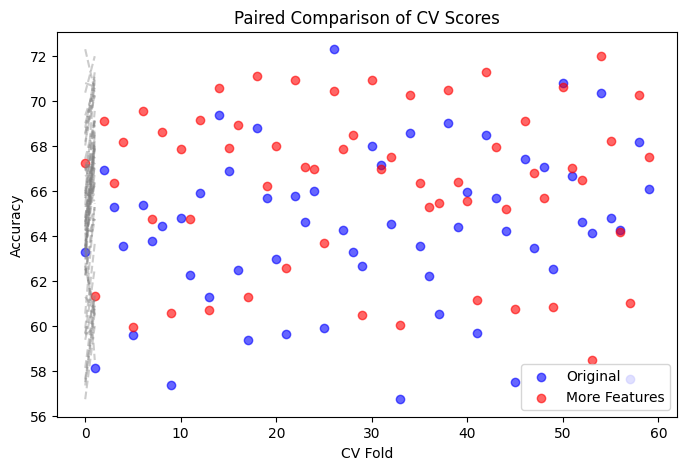

In [27]:
plt.figure(figsize=(8, 5))
plt.scatter(range(len(cv_original)), cv_original, color='blue', label='Original', alpha=0.6)
plt.scatter(range(len(cv_more)), cv_more, color='red', label='More Features', alpha=0.6)
plt.plot([cv_original, cv_more], color='gray', linestyle='--', alpha=0.4)
plt.xlabel('CV Fold')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Paired Comparison of CV Scores')
plt.show()